In [80]:
#run this everytime an edit is made in utils.py so that we can use the helper functions in this Python Notebook
import importlib
import utils
importlib.reload(utils)

<module 'utils' from '/Users/matthewliew/FINM 375-a/matthew-work/hw-1/utils.py'>

In [75]:
import pandas as pd
import numpy as np

#Loading in the description
descripion = pd.read_excel("option_data_bb_SFRZ5.xlsx", sheet_name="spot").set_index("Unnamed: 0")
display(descripion)

#Loading in the data from 2025-10-10
early_data = pd.read_excel("option_data_bb_SFRZ5.xlsx", sheet_name="2025-10-10")
display(early_data.head(3))

#Loading in the data from 2025-11-14
late_data = pd.read_excel("option_data_bb_SFRZ5.xlsx", sheet_name="2025-11-14")
display(late_data.head(3))


,SFRZ5 Comdty
Unnamed: 0,
name,3 MONTH SOFR FUT Dec25
last update date,2025-07-29 00:00:00
last update time,10:03:48
price,96.085
hist vol 30d,0.006851
hist vol 60d,0.007595
volume,150071


,ticker,last update date,last update time,days to expiration,option type,exercise style,option contract size,strike price,price,finance rate,...,delta,gamma,vega,theta,bid,ask,bid size,ask size,open int,volume
0,SFRV5C 95.75 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.7500,0.3300,0.04396,...,0.899011,0.028984,0.002962,-0.000265,0.335,0.350,51,51,10703,NaN
1,SFRV5C 95.8125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8125,0.2775,0.04396,...,0.847946,0.037543,0.003990,-0.000369,0.285,0.295,120,333,0,NaN
2,SFRV5C 95.875 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8750,0.2325,0.04396,...,0.768768,0.045176,0.005212,-0.000524,0.235,0.245,14976,119,20020,NaN


,ticker,last update date,last update time,days to expiration,option type,exercise style,option contract size,strike price,price,finance rate,...,delta,gamma,vega,theta,bid,ask,bid size,ask size,open int,volume
0,SFRX5C 95.75 Comdty,2025-07-28,2025-07-28,108,C,AMER,2500,95.7500,0.3400,0.0439,...,0.873209,0.030828,0.004216,-0.000228,0.345,0.355,281,376,0,NaN
1,SFRX5C 95.8125 Comdty,2025-07-28,2025-07-28,108,C,AMER,2500,95.8125,0.2925,0.0439,...,0.798810,0.037195,0.005785,-0.000355,0.295,0.305,733,202,0,NaN
2,SFRX5C 95.875 Comdty,2025-07-28,2025-07-28,108,C,AMER,2500,95.8750,0.2500,0.0439,...,0.730880,0.041992,0.006850,-0.000441,0.250,0.260,13147,185,1566,NaN


## 1.1.
Use Black’s Formula to price the call option
- at the nearest expiration
- using the ATM strike (strike nearest the spot)
- using the implied vol provided in the data
- using the finance rate as the discount rate
How close is your estimate to the market quote?

In [52]:
#Seperating into Call and Put Options

early_calls = early_data[early_data["option type"] =="C"]
early_puts = early_data[early_data["option type"] =="P"]

In [ ]:
#Grabbing the earliest exp
futures_price = descripion.loc["price"].iloc[0]
earliest_exp = early_calls["days to expiration"].sort_values(ascending=True).iloc[0]

#Grab the ATM option
stike_price_df = early_calls[["ticker", "strike price"]].copy()
stike_price_df["abs_diff_strike_to_price"] = (stike_price_df["strike price"] - futures_price).abs()                       
strike_price_df = stike_price_df.sort_values(ascending=True, by="abs_diff_strike_to_price")
ATM_ticker = strike_price_df.head(1)["ticker"].iloc[0]

atm_row = early_calls[early_calls["ticker"] == ATM_ticker]

#Grab strike
strike = atm_row["strike price"].iloc[0]

#Grab the earliest maturity
maturity_date = atm_row["days to expiration"].iloc[0] / 365

#grab discount rate
finance_rate = atm_row["finance rate"].iloc[0]
discount_factor = 1 / (1 + finance_rate * maturity_date)

#Grab the implied vol
implied_rate_vol = atm_row["implied vol"].iloc[0]
rate = (100 - futures_price)
vol_price = implied_rate_vol * (rate/futures_price)


print("Summary Table for ATM Call")
summary = pd.DataFrame({
    'metric': ['futures price', 'strike', 'maturity (years)', 'days to expiration',
               'finance rate', 'discount factor', 'vol price', 'ATM ticker'],
    'value': [futures_price, strike, maturity_date, earliest_exp,
              finance_rate, discount_factor, vol_price, ATM_ticker]
})
display(summary)

Summary Table for ATM Call


,metric,value
0,futures price,96.085
1,strike,96.0625
2,maturity (years),0.2
3,days to expiration,73
4,finance rate,0.04396
5,discount factor,0.991285
6,vol price,0.007556
7,ATM ticker,SFRV5C 96.0625 Comdty


In [70]:
model_pirce = utils.call_option_bond(expiration=maturity_date, 
                       strike=strike, vol=vol_price, 
                       forward_price=futures_price, discount_curve=discount_factor)

market_quote = atm_row["price"].iloc[0]

print(f"Difference between model and market quote {model_pirce - market_quote}")

Difference between model and market quote 0.009841664086242569


## 1.2.
Value the entire strike chain for the nearest expiration.

Use the provided implied vol for each strike.

Plot the Black values against the market values.

In [83]:
#Using helper function to price the put and call options
calls_model_price = utils.value_option_chain(option_data=early_calls,futures_price=futures_price)
puts_model_price = utils.value_option_chain(option_data=early_puts,futures_price=futures_price, option_type="P")

display(calls_model_price.head(3))
display(puts_model_price.head(3))

,strike price,price,model price,difference
0,95.7500,0.3300,0.341699,0.011699
1,95.8125,0.2775,0.286890,0.009390
2,95.8750,0.2325,0.239752,0.007252


,strike price,price,model price,difference
11,95.7500,0.0075,0.006301,-0.001199
12,95.8125,0.0175,0.014631,-0.002869
13,95.8750,0.0350,0.029460,-0.005540


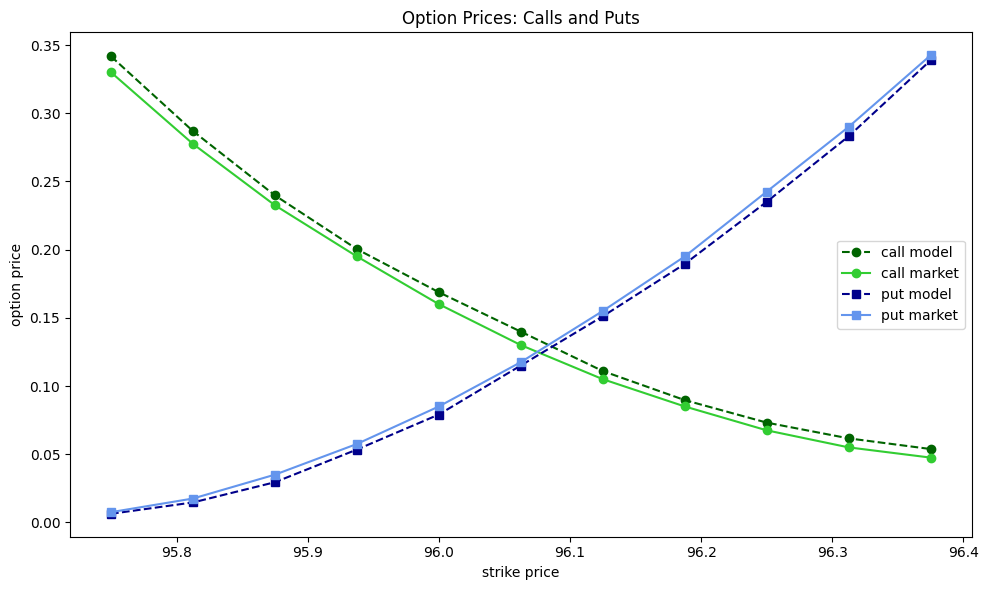

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Calls
ax.plot(calls_model_price['strike price'], calls_model_price['model price'], 
        'o--', color='darkgreen', label='call model')
ax.plot(calls_model_price['strike price'], calls_model_price['price'], 
        'o-', color='limegreen', label='call market')

# Puts
ax.plot(puts_model_price['strike price'], puts_model_price['model price'], 
        's--', color='darkblue', label='put model')
ax.plot(puts_model_price['strike price'], puts_model_price['price'], 
        's-', color='cornflowerblue', label='put market')

ax.set_xlabel('strike price')
ax.set_ylabel('option price')
ax.set_title('Option Prices: Calls and Puts')
ax.legend()
plt.tight_layout()
plt.show()

## 1.3.
What are a few reasons that Black’s value doesn’t match the market value?

How significant is the American nature of the exercise?

Black’s values may differ from market prices due to model assumptions such as lognormal forward prices, constant volatility, deterministic interest rates, and the static treatment of the volatility smile. Additional discrepancies arise from bid–ask spreads, discretization of implied volatilities, and small errors in forward or discount factor construction. Although the options are American-style, the value of early exercise for futures options is typically very small, so treating them as European under Black’s model introduces only a minor error.

## 1.4.
How is implied vol being quoted? As in, does it reflect units of vol of percent changes in the SOFR rate? Or day-over-day differences? Or something else?

Use the data in ref_rates.xlsx to calculate the historic 60-day rolling volatility of the SOFR rate.

the implied vol column is in rate volatility terms — it's the lognormal vol of the SOFR rate (not the futures price). That's why the values are ~18-19%, which makes sense as vol of a ~3.9% rate, but would be nonsensical as vol of a ~96 futures price.

In [ ]:
refrence_sofr = pd.read_excel("ref_rates.xlsx", sheet_name="data")
sofr = refrence_sofr

In [ ]:
sofr_clean = sofr[sofr["SOFR"] > 0].copy()
log_returns = np.log(sofr_clean["SOFR"] / sofr_clean["SOFR"].shift(1))
sofr_clean["rolling_vol_60d"] = log_returns.rolling(60).std() * np.sqrt(252)

print(sofr_clean[sofr_clean["date"] == "2025-07-28"])
sofr_clean[["date", "rolling_vol_60d"]].tail()

           date  DTB3   DFF  SOFR  rolling_vol_60d
2765 2025-07-28  4.24  4.33  4.36         0.090651


,date,rolling_vol_60d
2914,2025-12-24,0.270272
2916,2025-12-26,0.276526
2919,2025-12-29,0.270537
2920,2025-12-30,0.271648
2921,2025-12-31,0.286402


## 1.5.
Plot the open interest across strikes.

Report the total notional open interest across the chain for this expiration.

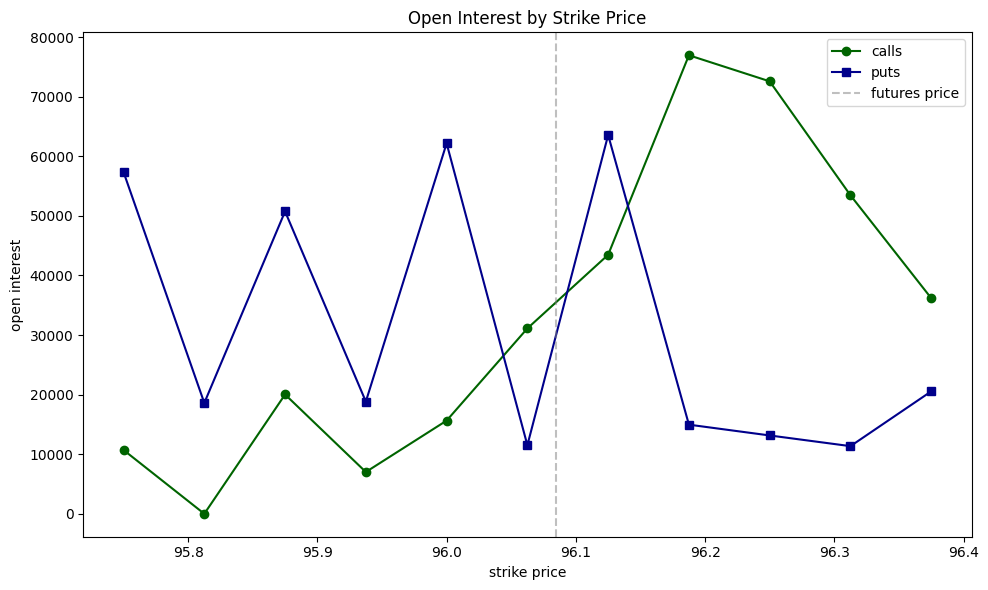

Total notional open interest: $1,774,437,500


In [110]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(early_calls['strike price'], early_calls['open int'], 
        'o-', color='darkgreen', label='calls')
ax.plot(early_puts['strike price'], early_puts['open int'], 
        's-', color='darkblue', label='puts')

ax.axvline(x=futures_price, color='gray', linestyle='--', alpha=0.5, label='futures price')
ax.set_xlabel('strike price')
ax.set_ylabel('open interest')
ax.set_title('Open Interest by Strike Price')
ax.legend()
plt.tight_layout()
plt.show()

# Total notional open interest
contract_size = early_calls['option contract size'].iloc[0]
total_oi = (early_calls['open int'].sum() + early_puts['open int'].sum()) * contract_size
print(f"Total notional open interest: ${total_oi:,.0f}")

The key takeaway: open interest tells you where the market's positioning is concentrated. High put OI below the current price and high call OI above it is a typical pattern — it reflects the market hedging both directions around the current futures price. The spikes at certain strikes (like round numbers or quarter-point intervals) are common because those are the most liquid and popular strikes to trade.